<a href="https://colab.research.google.com/github/ochilovu2010/IOAI/blob/main/NitroAI/Sentinal_of_the_servers.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#https://judge.nitro-ai.org/competitions?page=1

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [5]:
train = pd.read_csv('/content/train.csv')
test = pd.read_csv('/content/test.csv')

In [6]:
train

,timestamp,sensor_0,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,sensor_6,sensor_7,sensor_8,...,sensor_28,sensor_29,sensor_30,sensor_31,sensor_32,sensor_33,sensor_34,sensor_35,sensor_36,sensor_37
0,0,0.032258,0.039195,0.027871,0.024390,0.0,0.915385,0.343691,0.0,0.020011,...,0.0,0.004298,0.029993,0.022131,0.000000,0.000045,0.034677,0.034747,0.0,0.0
1,1,0.043011,0.048729,0.033445,0.025552,0.0,0.915385,0.344633,0.0,0.019160,...,0.0,0.004298,0.030041,0.028821,0.000000,0.000045,0.035763,0.035833,0.0,0.0
2,2,0.043011,0.034958,0.032330,0.025552,0.0,0.915385,0.344633,0.0,0.020011,...,0.0,0.004298,0.026248,0.021101,0.000000,0.000045,0.033012,0.033082,0.0,0.0
3,3,0.032258,0.028602,0.030100,0.024390,0.0,0.912821,0.342750,0.0,0.021289,...,0.0,0.004298,0.030169,0.025733,0.000000,0.000022,0.035112,0.035182,0.0,0.0
4,4,0.032258,0.019068,0.026756,0.023229,0.0,0.912821,0.342750,0.0,0.018734,...,0.0,0.004298,0.027240,0.022645,0.000000,0.000034,0.033447,0.033517,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28474,28474,0.075269,0.046610,0.071349,0.076655,0.0,0.928205,0.269303,0.0,0.031649,...,0.0,0.008596,0.068980,0.049408,0.000386,0.000034,0.064504,0.064572,0.0,0.0
28475,28475,0.086022,0.070975,0.075808,0.077816,0.0,0.930769,0.269303,0.0,0.029946,...,0.0,0.008596,0.073029,0.055584,0.000386,0.000034,0.067690,0.067757,0.0,0.0
28476,28476,0.086022,0.065678,0.073579,0.076655,0.0,0.935897,0.270245,0.0,0.030372,...,0.0,0.008596,0.070516,0.048893,0.000386,0.000034,0.064866,0.064934,0.0,0.0
28477,28477,0.086022,0.056144,0.068004,0.074332,0.0,0.933333,0.271186,0.0,0.032643,...,0.0,0.008596,0.070308,0.055069,0.000386,0.000045,0.067111,0.067178,0.0,0.0


In [7]:
test['datapointID'] = test['timestamp'].apply(lambda x: f"ts_{x:05d}")

In [8]:
test

,timestamp,sensor_0,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,sensor_6,sensor_7,sensor_8,...,sensor_29,sensor_30,sensor_31,sensor_32,sensor_33,sensor_34,sensor_35,sensor_36,sensor_37,datapointID
0,0,0.075269,0.065678,0.070234,0.074332,0.0,0.933333,0.274011,0.0,0.031081,...,0.008596,0.068036,0.048893,0.000386,0.000034,0.064432,0.064500,0.0,0.0,ts_00000
1,1,0.086022,0.080508,0.075808,0.076655,0.0,0.930769,0.274953,0.0,0.031081,...,0.008596,0.070020,0.050437,0.000386,0.000022,0.065228,0.065224,0.0,0.0,ts_00001
2,2,0.075269,0.064619,0.071349,0.074332,0.0,0.928205,0.274953,0.0,0.030940,...,0.008596,0.069684,0.055069,0.000386,0.000045,0.067111,0.067178,0.0,0.0,ts_00002
3,3,0.086022,0.048729,0.063545,0.070848,0.0,0.928205,0.273070,0.0,0.027250,...,0.010029,0.073253,0.051467,0.000000,0.000034,0.066676,0.066744,0.0,0.0,ts_00003
4,4,0.086022,0.051907,0.062430,0.070848,0.0,0.933333,0.274011,0.0,0.030940,...,0.008596,0.070932,0.051467,0.000386,0.000022,0.066604,0.066671,0.0,0.0,ts_00004
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28474,28474,0.075269,0.051907,0.047938,0.047619,0.0,0.907692,0.257062,0.0,0.043571,...,0.031519,0.046733,0.040144,0.000000,0.000022,0.042931,0.043000,0.0,0.0,ts_28474
28475,28475,0.064516,0.025424,0.039019,0.044135,0.0,0.905128,0.257062,0.0,0.032501,...,0.031519,0.047438,0.048893,0.000000,0.000056,0.046550,0.046619,0.0,0.0,ts_28475
28476,28476,0.064516,0.080508,0.050167,0.047619,0.0,0.907692,0.258004,0.0,0.026114,...,0.031519,0.046797,0.040144,0.000386,0.000045,0.043003,0.043000,0.0,0.0,ts_28476
28477,28477,0.064516,0.056144,0.047938,0.046458,0.0,0.902564,0.257062,0.0,0.033210,...,0.031519,0.041884,0.043232,0.000000,0.000045,0.039890,0.039959,0.0,0.0,ts_28477


In [9]:
submission = pd.DataFrame({
    'subtaskID': 1,
    'datapointID':test['datapointID'],
    'answer':0,
})

In [10]:
submission.to_csv("baseline_submission.csv", index = False)

In [11]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

In [12]:
visual = PCA(n_components = 2)

In [13]:
data = visual.fit_transform(train.drop(columns = ['timestamp']))

In [14]:
data.shape

(28479, 2)

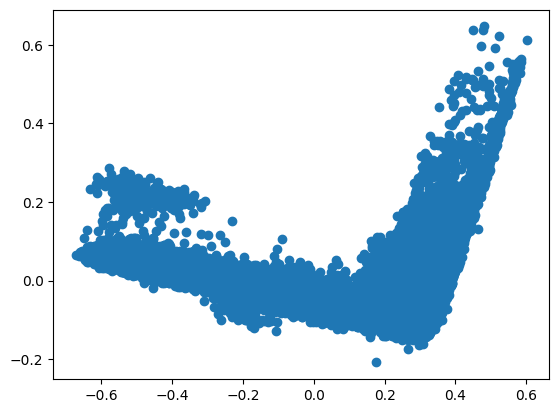

In [15]:
plt.scatter(data[:, 0], data[:, 1])

In [16]:
test_data = visual.transform(test.drop(columns = ['timestamp', 'datapointID']))
print(test_data.shape)

(28479, 2)


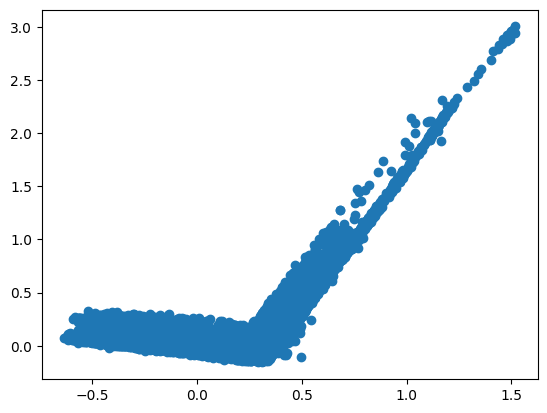

In [17]:
plt.scatter(test_data[:, 0], test_data[:,1])

In [18]:
merged = np.concatenate([data, test_data], axis = -1)
merged.shape

(28479, 4)

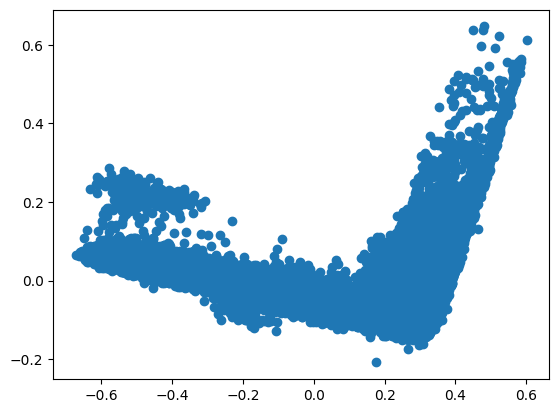

In [19]:
plt.scatter(merged[:, 0], merged[:, 1])

In [20]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import SpectralClustering, KMeans
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import adjusted_rand_score
combined = pd.concat([train.drop(columns = ['timestamp']), test.drop(columns = ['timestamp', 'datapointID'])])

In [21]:
scaler = StandardScaler()
scaled = scaler.fit_transform(combined)

In [22]:
cluster = KMeans(n_clusters = 2)
cluster.fit(scaled)

KMeans(n_clusters=2)

In [23]:
train_scaled = scaler.transform(train.drop(columns = ['timestamp']))
test_scaled = scaler.transform(test.drop(columns = ['timestamp', 'datapointID']))
predictions = cluster.predict(train_scaled)
test_predictions = cluster.predict(test_scaled)

In [24]:
np.sum(test_predictions)


np.int64(4075)

In [25]:
submission = pd.DataFrame({
    'subtaskID': 1,
    'datapointID':test['datapointID'],
    'answer':test_predictions,
})

In [26]:
submission.to_csv("submission.csv", index = False)

In [32]:
import numpy as np
import pandas as pd
from sklearn.neighbors import NearestNeighbors

TRAIN_CSV = "/content/train.csv"
TEST_CSV  = "/content/test.csv"

K          = 5
FLAG_QUANT = 0.975
MERGE_GAP  = 180
MIN_LEN    = 20

tr = pd.read_csv(TRAIN_CSV).dropna(axis=1, how="all")
te = pd.read_csv(TEST_CSV).dropna(axis=1, how="all")
X = tr.drop(columns=["timestamp"]).values.astype(np.float64)
Y = te.drop(columns=["timestamp"]).values.astype(np.float64)

keep = X.std(0) > 0
X, Y = X[:, keep], Y[:, keep]
mu, sd = X.mean(0), X.std(0)
Xs, Ys = (X - mu) / sd, (Y - mu) / sd

nn = NearestNeighbors(n_neighbors=K, n_jobs=-1).fit(Xs)
dist, _ = nn.kneighbors(Ys)
score = dist[:, -1]
print(dist.shape, score.shape)
print(dist, score)
seed = score > np.quantile(score, FLAG_QUANT)
def find_runs(mask):
    """Return [(start, end), ...] half-open intervals where mask is True."""
    d = np.diff(np.r_[0, mask.astype(int), 0])
    return list(zip(np.where(d == 1)[0], np.where(d == -1)[0]))

merged = []
for a, b in find_runs(seed):
    if merged and a - merged[-1][1] < MERGE_GAP:
        merged[-1] = (merged[-1][0], b)
    else:
        merged.append((a, b))

pred = np.zeros(len(Ys), dtype=int)
for a, b in merged:
    if b - a >= MIN_LEN:
        pred[a:b] = 1

ts = te["timestamp"].astype(int).values
sub = pd.DataFrame({
    "subtaskID": 1,
    "datapointID": [f"ts_{t:05d}" for t in ts],
    "answer": pred,
})
sub.to_csv("task3_submission.csv", index=False)
print(f"flagged {pred.sum()} / {len(pred)} timestamps ({pred.mean():.2%})")

flagged 2481 / 28479 (8.71%)


In [31]:
print(np.quantile(score,))

20.922139971584585
